# TP2 Analyse Numérique
# Mathys PRIMA - Ugo NOWAK groupe TP4

## Exercice 1:

1)

In [58]:
import numpy as np
from math import ceil
from scipy.optimize import fsolve

def resoudre_edo(f, y0, t0, tf, delta_t):

    N = int(ceil((tf - t0)/delta_t))
    delta_t = (tf - t0)/N
    
    tn = np.zeros(N+1)
    yn = np.zeros(N+1)
    
    yn[0] = y0
    tn[0] = t0

    for i in range (1, N):
        yn[i] = yn[i-1] + delta_t * f(tn[i-1], yn[i-1])
        tn[i] = delta_t + tn[i-1]
        
    return tn, yn



2)

In [68]:
def euler_explicite(f, tn, yn, delta_t):
    N = len(yn)
    for i in range (1, N):
        yn[i] = yn[i-1] + delta_t * f(tn[i-1], yn[i-1])
        tn[i] = delta_t + tn[i-1]
    return yn, tn
    

In [69]:
def resoudre_edo2(f, y0, t0, tf, delta_t, schema):

    N = int(ceil((tf - t0)/delta_t))
    delta_t = (tf - t0)/N
    
    tn = np.zeros(N+1)
    yn = np.zeros(N+1)
    
    yn[0] = y0
    tn[0] = t0
 
    return schema(f, tn, yn, delta_t)

3)

In [83]:
def heun(f, tn, yn, delta_t):
    N = len(yn)
    for i in range (1, N):
        yn[i] = yn[i-1] + delta_t * f(tn[i-1], yn[i-1])
        yn[i] = yn[i-1] + delta_t/2 * (f(tn[i-1], yn[i-1]) + f(tn[i-1], yn[i]))
        tn[i] = delta_t + tn[i-1]
    return yn, tn

In [104]:
def RK4 (f, tn, yn, delta_t):
    N = len(yn)
    
    for i in range (1, N):
        k1 = f(tn[i-1],yn[i-1])
        k2 = f(tn[i-1] + delta_t/2, yn[i-1] + delta_t*k1/2)
        k3 = f(tn[i-1] + delta_t/2, yn[i-1] + delta_t*k2/2)
        k4 = f(tn[i-1] + delta_t, yn[i-1] + delta_t*k3)
        yn[i] = yn[i-1] + (delta_t/6) * (k1 + 2*k2 + 2*k3 + k4)
        tn[i] = delta_t + tn[i-1]
    return yn, tn

In [72]:
def euler_implicite(f, tn, yn, delta_t):
    n = len(yn)
    for i in range(1,n):
        tn[i] = tn[i-1] + delta_t
        equation = lambda y: y- yn[i-1] -delta_t*f(tn[i],y)
        yn[i] = fsolve(equation,yn[i-1])[0]
    return yn, tn


In [73]:
def crank_nicolson(f, tn, yn, delta_t):
    n = len(yn) 
    for i in range(1,n):
        tn[i] = tn[i-1] + delta_t
        equation = lambda y: y- yn[i-1] -delta_t/2*(f(tn[i],y)+f(tn[i-1],yn[i-1]))
        yn[i] = fsolve(equation,yn[i-1])[0]
    return yn, tn


4)

In [74]:
def ordre_de_conv(schema, y_reel, delta_t, c):
    n = len(yn)
    max = schema[0][0] - y_reel(schema[1][0])
    for i in range(1,n): 
        if schema[0][i] - y_reel(schema[1][i])>max:
            max = schema[0][i] - y_reel(schema[1][i])
    p = log(max)/log(c*delta_t)
    return p

## Exercice 2:

1)

In [149]:
import math
def f(t,y):
    return np.exp(-10*y)
    
def y_exacte(t):
    return 1/10*np.log(10*t+np.exp(1))

In [140]:
resoudre_edo2(f, 0.1, 0, 5, 0.5 ,euler_explicite)

(array([0.1       , 0.28393972, 0.31317017, 0.3349919 , 0.3525355 ,
        0.36725618, 0.37996182, 0.39115148, 0.40115656, 0.41020908,
        0.41847811]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]))

In [141]:
resoudre_edo2(f, 0.1, 0, 5, 0.5 ,heun)

(array([0.1       , 0.20658508, 0.2550741 , 0.28778513, 0.31246469,
        0.33227306, 0.34881334, 0.36300984, 0.37544367, 0.38650383,
        0.39646343]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]))

In [142]:
resoudre_edo2(f, 0.1, 0, 5, 0.5 , RK4)

(array([0.1       , 0.20616059, 0.25542138, 0.28826509, 0.31294613,
        0.33272529, 0.34923083, 0.36339407, 0.37579793, 0.38683163,
        0.39676797]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]))

In [143]:
resoudre_edo2(f, 0.1, 0, 5, 0.5 , euler_implicite)

(array([0.1       , 0.18145533, 0.23105745, 0.26602338, 0.29278056,
        0.31434699, 0.33235869, 0.34779414, 0.36128197, 0.3732486 ,
        0.38399585]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]))

In [144]:
resoudre_edo2(f, 0.1, 0, 5, 0.5 , crank_nicolson)

(array([0.1       , 0.21974216, 0.26515068, 0.29577128, 0.3190441 ,
        0.33785661, 0.35365881, 0.36728775, 0.37927211, 0.38996777,
        0.39962595]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]))

2)

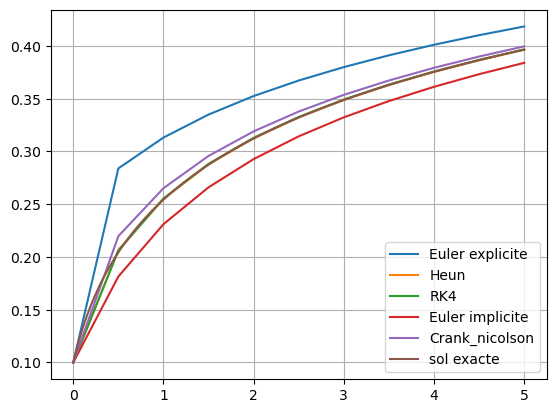

In [151]:
import matplotlib.pyplot as plt

res1 = resoudre_edo2(f, 0.1, 0, 5, 0.5, euler_explicite)
res2 = resoudre_edo2(f, 0.1, 0, 5, 0.5, heun)
res3 = resoudre_edo2(f, 0.1, 0, 5, 0.5 , RK4)
res4 = resoudre_edo2(f, 0.1, 0, 5, 0.5 , euler_implicite)
res5 = resoudre_edo2(f, 0.1, 0, 5, 0.5 , crank_nicolson)
plt.grid(True)

plt.plot(res1[1], res1[0], label="Euler explicite")
plt.plot(res2[1], res2[0], label="Heun")
plt.plot(res3[1], res3[0], label="RK4")
plt.plot(res4[1], res4[0], label="Euler implicite")
plt.plot(res5[1], res5[0], label="Crank_nicolson")
x = np.linspace(0,5,100)
y = y_exacte(x)
plt.plot(x,y,label="sol exacte")


plt.legend()
plt.show()

La méthode RK4 est la plus précise des méthodes utilisées ici.

3)

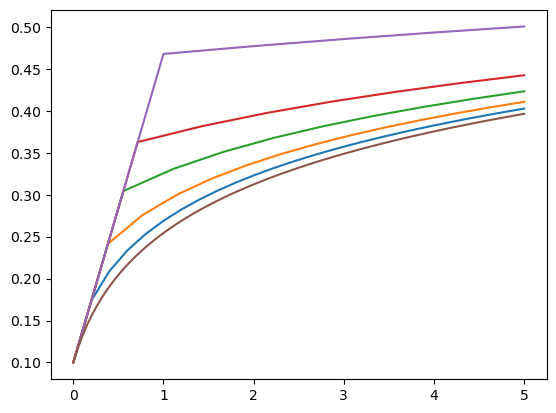

In [152]:
res1 = resoudre_edo2(f, 0.1, 0, 5, 0.2, euler_explicite)
res2 = resoudre_edo2(f, 0.1, 0, 5, 0.4, euler_explicite)
res3 = resoudre_edo2(f, 0.1, 0, 5, 0.6 , euler_explicite)
res4 = resoudre_edo2(f, 0.1, 0, 5, 0.8 , euler_explicite)
res5 = resoudre_edo2(f, 0.1, 0, 5, 1 , euler_explicite)

plt.plot(res1[1], res1[0], label="Euler explicite")
plt.plot(res2[1], res2[0], label="Euler explicite")
plt.plot(res3[1], res3[0], label="Euler explicite")
plt.plot(res4[1], res4[0], label="Euler explicite")
plt.plot(res5[1], res5[0], label="Euler explicite")

x = np.linspace(0,5,100)
y = y_exacte(x)
plt.plot(x,y,label="sol exacte")

Plus la valeur de $\Delta t$ est faible plus la solution sera précise

## Exercice 3:

On a l'équation différentielle du second ordre :
$$x''(t) + \lambda x'(t) + \omega_0^2 x(t) = A\cos(\omega t)$$
avec $x(0)=0$, $x'(0)=0$ et les paramètres $\lambda=0.1$, $\omega_0=1$, $A=1$.

1)

On pose $v_1(t) = x(t)$ et $v_2(t) = x'(t)$.  
On obtient le système d'ordre 1 :

$$\begin{cases}
v_1'(t) = v_2(t) \\
v_2'(t) = A\cos(\omega t) - \lambda v_2(t) - \omega_0^2 v_1(t)
\end{cases}$$

avec $v_1(0) = 0$, $v_2(0) = 0$.  

2)

In [ ]:
def resoudre_systeme(F, V0, t0, tf, delta_t, schema_sys):
    N = int(ceil((tf - t0) / delta_t))
    delta_t = (tf - t0) / N